# Question 2: Convergence of a walk on a discrete lattice

We simulate the lattice walk

$$X_{n+1} = X_n \pm \sigma\sqrt{\Delta t}, \qquad p = \tfrac12\left[1 + \tfrac{\alpha}{\sigma}\sqrt{\Delta t}\right], \qquad \Delta t = T/N,$$

which converges to the SDE $dX = \alpha\,dt + \sigma\,dZ$ as $\Delta t \to 0$. The exact $X(T)$ is normal with mean $X_{init} + \alpha T$ and standard deviation $\sigma\sqrt{T}$.

The walk is vectorized: the only explicit loop is over the $N$ timesteps. At each step, every simulation is updated at once, and only the current column of the lattice (one value of $X$ per simulation) is kept in memory.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

%matplotlib inline

In [2]:
# Parameters (Table 1)
T = 1.75
sigma = 0.3
alpha = 0.4
X_init = 17.0
N = 300
sim_counts = [1000, 10000, 100000]

dt = T / N
sqrt_dt = np.sqrt(dt)
p = 0.5 * (1.0 + (alpha / sigma) * sqrt_dt)

exact_mean = X_init + alpha * T
exact_std = sigma * np.sqrt(T)

print(f"dt = {dt:.6f}, p = {p:.6f}")
print(f"Exact mean = {exact_mean:.6f}, exact std = {exact_std:.6f}")

dt = 0.005833, p = 0.550918
Exact mean = 17.700000, exact std = 0.396863


In [3]:
def lattice_walk(n_sims, N, X_init, sigma, dt, p, rng):
    """Return X_N for n_sims independent lattice walks.

    Loops only over timesteps; every simulation is updated together.
    Only the current column of the lattice (length n_sims) is stored.
    """
    X = np.full(n_sims, X_init)
    step = sigma * np.sqrt(dt)
    for _ in range(N):
        U = rng.uniform(0.0, 1.0, n_sims)   # one uniform draw per simulation
        X = X + np.where(U < p, step, -step)  # up with prob p, down with prob 1-p
    return X

In [4]:
rng = np.random.default_rng(seed=12345)  # fixed seed for reproducibility

results = {}
print(f"{'# sims':>8} | {'sim mean':>10} | {'exact mean':>10} | {'sim std':>9} | {'exact std':>9}")
print("-" * 58)
for n_sims in sim_counts:
    X_N = lattice_walk(n_sims, N, X_init, sigma, dt, p, rng)
    results[n_sims] = X_N
    print(f"{n_sims:>8} | {np.mean(X_N):>10.6f} | {exact_mean:>10.6f} | "
          f"{np.std(X_N):>9.6f} | {exact_std:>9.6f}")

  # sims |   sim mean | exact mean |   sim std | exact std
----------------------------------------------------------
    1000 |  17.704342 |  17.700000 |  0.397991 |  0.396863
   10000 |  17.698064 |  17.700000 |  0.387892 |  0.396863


  100000 |  17.697891 |  17.700000 |  0.393008 |  0.396863


## Probability density histograms

The possible outcomes at timestep $N$ are the lattice nodes $X_N^j = X_{init} + (2j - N)\sigma\sqrt{\Delta t}$, $j = 0,\dots,N$, spaced $2\sigma\sqrt{\Delta t}$ apart. We use $N+1$ bins whose boundaries fall half-way between neighbouring nodes, so each bin holds exactly one node and has width $b - a = 2\sigma\sqrt{\Delta t}$. The density estimate at the bin centre is

$$p\!\left(\tfrac{a+b}{2}\right) \approx \frac{1}{b-a}\,\frac{\text{number of occurrences in bin}_{[a,b]}}{\text{total number of occurrences}}.$$

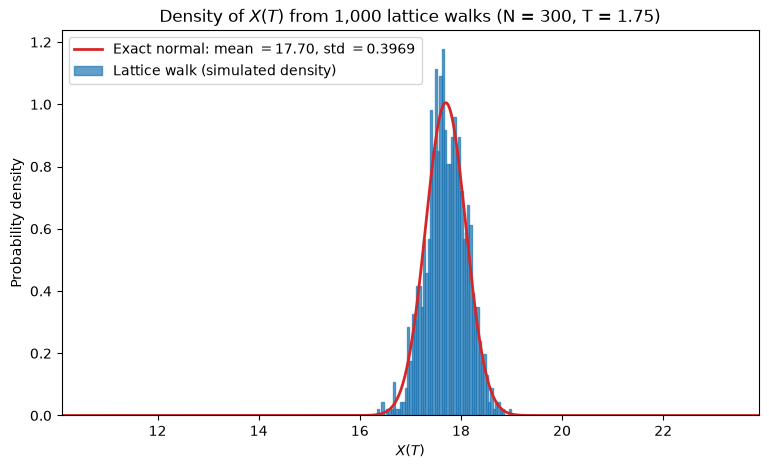

1000 sims: area under histogram = 1.000000


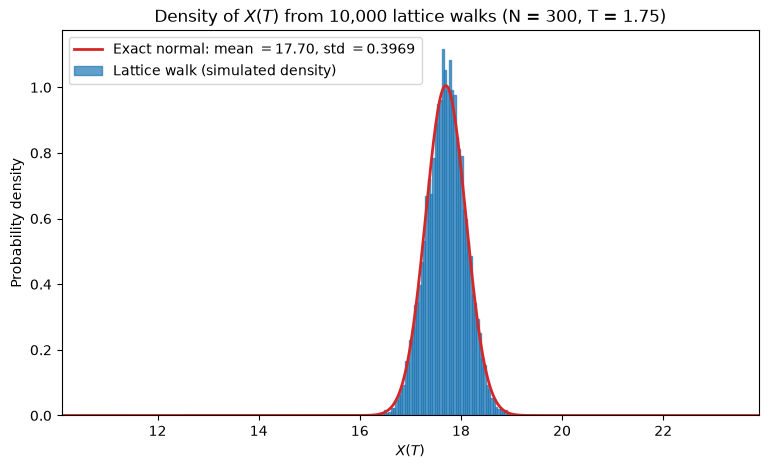

10000 sims: area under histogram = 1.000000


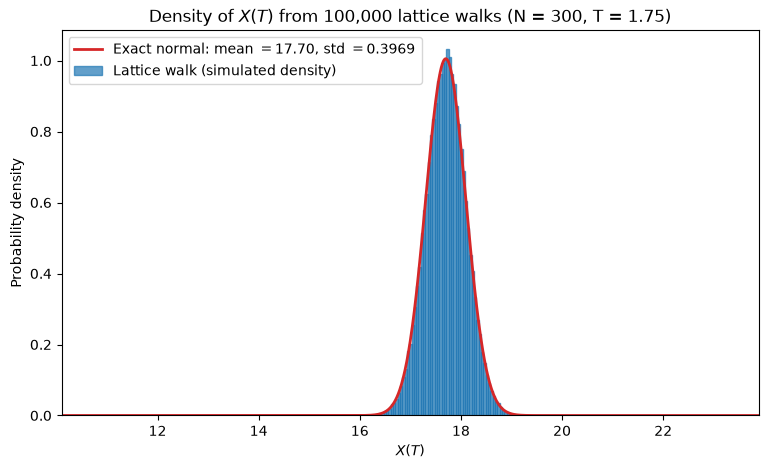

100000 sims: area under histogram = 1.000000


In [5]:
# Lattice nodes at timestep N, and bin edges half-way between them
j = np.arange(N + 1)
nodes = X_init + (2 * j - N) * sigma * sqrt_dt
bin_width = 2 * sigma * sqrt_dt
edges = np.concatenate(([nodes[0] - bin_width / 2], nodes + bin_width / 2))

# Exact normal density over the same range
x_line = np.linspace(edges[0], edges[-1], 2000)
exact_pdf = stats.norm.pdf(x_line, loc=exact_mean, scale=exact_std)

for n_sims in sim_counts:
    X_N = results[n_sims]
    counts, _ = np.histogram(X_N, bins=edges)
    density = counts / (n_sims * bin_width)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(nodes, density, width=bin_width, color="tab:blue", edgecolor="tab:blue",
           alpha=0.7, label="Lattice walk (simulated density)")
    ax.plot(x_line, exact_pdf, color="tab:red", linewidth=2,
            label=rf"Exact normal: mean $= {exact_mean:.2f}$, std $= {exact_std:.4f}$")
    ax.set_xlim(edges[0], edges[-1])
    ax.set_xlabel(r"$X(T)$")
    ax.set_ylabel("Probability density")
    ax.set_title(f"Density of $X(T)$ from {n_sims:,} lattice walks (N = {N}, T = {T})")
    ax.legend()
    plt.show()

    # Sanity check: the histogram integrates to 1
    print(f"{n_sims} sims: area under histogram = {np.sum(density * bin_width):.6f}")

## Observations

**Statistics.** In every case the sample mean and standard deviation of $X_N$ are close to the exact values $X_{init} + \alpha T = 17.7$ and $\sigma\sqrt{T} \approx 0.3969$. As the number of simulations grows from 1,000 to 100,000, the sample statistics generally move closer to the exact values. The sampling error of the mean is about $\sigma\sqrt{T}/\sqrt{M}$ for $M$ simulations, so it shrinks by roughly a factor of $\sqrt{10} \approx 3.2$ each time $M$ grows tenfold (about 0.0126, 0.0040 and 0.0013 for $M$ = 1,000, 10,000 and 100,000). Any single run can be a little better or worse by chance, but the trend follows this $1/\sqrt{M}$ rate.

**Plots.** With 1,000 simulations the histogram is ragged: many bins hold only a few walks, so neighbouring bars jump up and down around the red normal curve. With 10,000 simulations the bell shape is clear and the bars follow the curve more closely. With 100,000 simulations the histogram sits almost exactly on the exact normal density, with only small fluctuations left. All three histograms have area 1, as a density should.

**Two sources of error.** The mismatch between histogram and curve comes from two places:
1. *Monte Carlo (sampling) error* from using a finite number of walks $M$. It shrinks like $1/\sqrt{M}$, and this is the improvement we see from 1,000 to 100,000 simulations.
2. *Discretization error* from the lattice itself ($N = 300$, so $\Delta t$ is finite). $X_N$ can only land on the $N+1$ lattice nodes and follows a (shifted, scaled) binomial distribution rather than an exact normal one. Adding more simulations does not remove this error. Only increasing $N$ (letting $\Delta t \to 0$) does. With $N = 300$ it is already too small to see next to the sampling noise. The lattice mean $X_{init} + N(2p-1)\sigma\sqrt{\Delta t} = X_{init} + \alpha T$ is exact, and the lattice variance $4p(1-p)\,\sigma^2 T = \sigma^2 T - \alpha^2 T\,\Delta t$ is only slightly below $\sigma^2 T$. That puts the lattice standard deviation at about 0.3948 instead of 0.3969. So even with unlimited simulations, the sample standard deviation would settle about 0.002 below the exact SDE value. At 100,000 simulations this gap is about the same size as the sampling noise (about 0.0009).

Overall, the experiment confirms that the lattice walk converges in distribution to the solution of $dX = \alpha\,dt + \sigma\,dZ$, a normal density with mean $X_{init} + \alpha T$ and standard deviation $\sigma\sqrt{T}$.